In [1]:
import sys
sys.path.append('../src/')

from cryosim import atom
import matplotlib.pyplot as plt
import mrcfile
from cryosim import pdbtools
from cryosim import potential
import torch
from tqdm import tqdm
from cryosim.plotting_tools import plot3d, plot_slices

%load_ext autoreload
%autoreload 2

In [5]:
N = 256
dx = 0.01
elem = 90

x, y, X, Y = potential.coordinate_grid_2d((N, N), (dx, dx))
R = torch.sqrt(X**2 + Y**2)

x, y, z, X, Y, Z = potential.coordinate_grid_3d((N, N, N), (dx, dx, dx))
R3 = torch.sqrt(X**2 + Y**2 + Z**2)

pot = potential.kirkland_atomic_potential_2d(elem, R)
pot3 = potential.kirkland_atomic_potential_3d(elem, R3)
lobpot3 = potential.lobato_atomic_potential_3d(elem, R3)

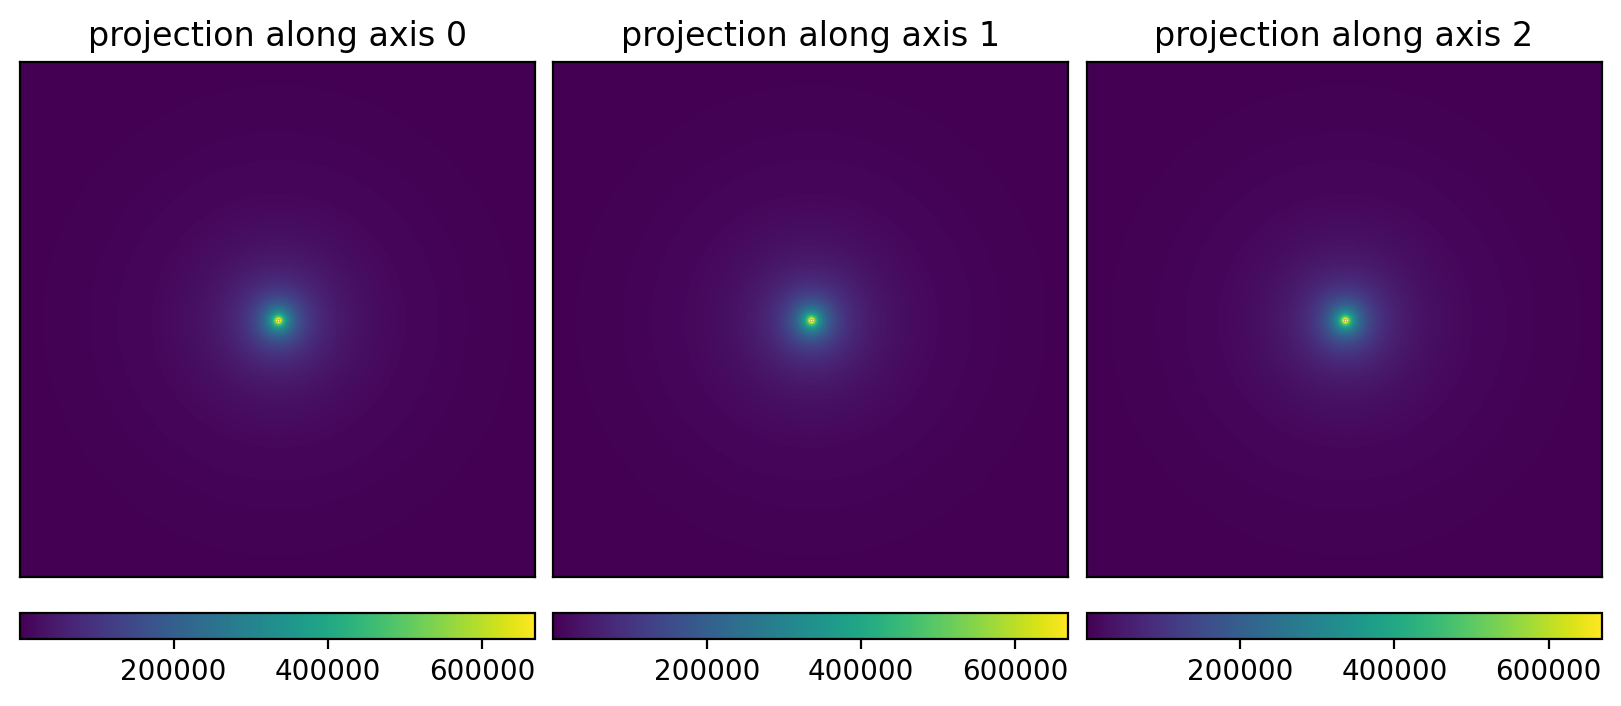

In [6]:
plot3d(lobpot3)

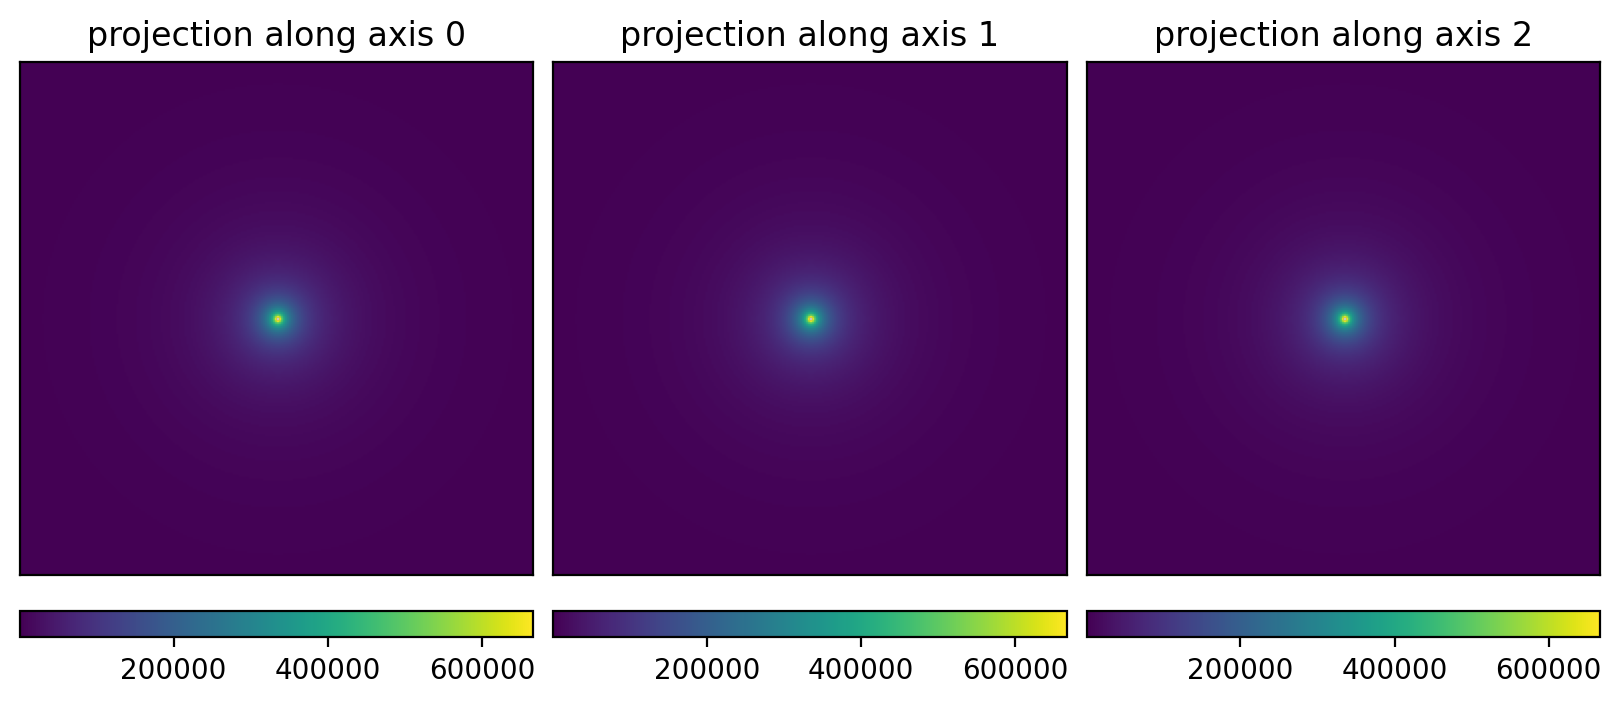

In [7]:
plot3d(pot3)

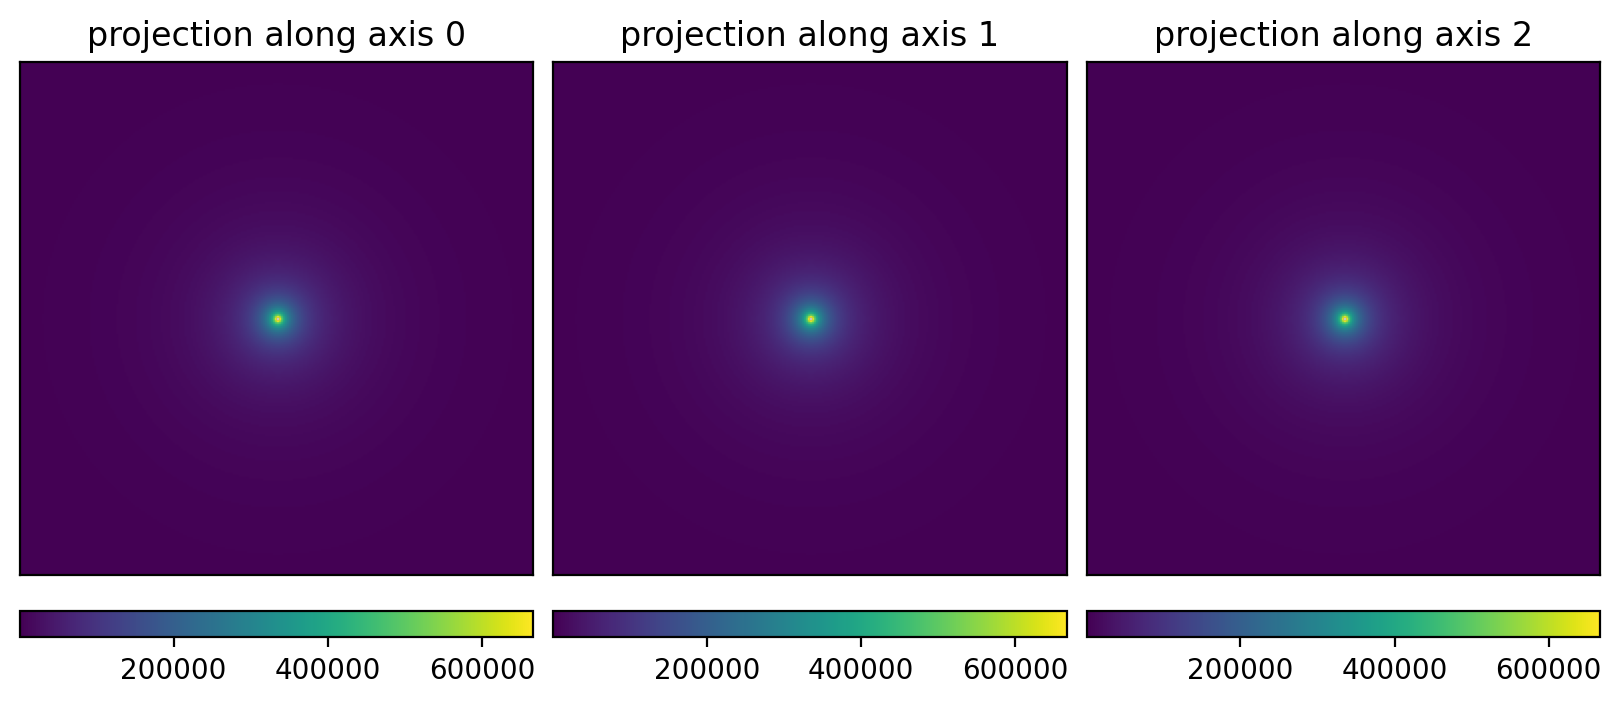

In [104]:
plot3d(oldpot3)

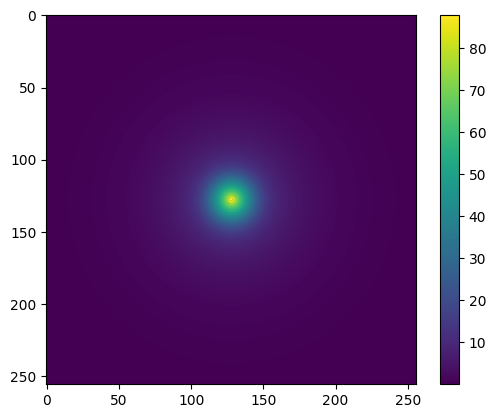

In [83]:
plt.imshow(pot)
plt.colorbar()

In [53]:
params = load_kirkland_parameters()

In [55]:
params[1].shape

torch.Size([3, 4])

## Plotting functions

## Download PDB file

In [2]:
folder = '../pdb-data/'
filename = pdbtools.fetch_pdb_file("6bdf", output=folder)
filename

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.


'../pdb-data/6bdf-assembly1.cif'

## Extract atomic coordinates and recenter onto (0,0,0)

In [4]:
# extracts raw coordinates for each atom in (x,y,z) order from pdb file
assemble = True
atomic_numbers, coords = pdbtools.get_atoms_and_coordinates_from_pdb(filename)
atomic_numbers.shape, coords.shape

Parsing ../pdb-data/6bdf-assembly1.cif.


Extracting atom coordinates and element: 46382it [00:00, 169878.89it/s]


(torch.Size([46382]), torch.Size([46382, 3]))

In [5]:
# elements in particle
print(set(atom.atom_symbol(atomic_numbers)))

{np.str_('O'), np.str_('C'), np.str_('S'), np.str_('N')}


In [6]:
coords.shape

torch.Size([46382, 3])

In [7]:
# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

## Compute volumetric potential from PDB (2D Projection, Snap)

In [8]:
dx = 1
n = 256
super_sampling_factor = 4
vol_snapped_2d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-2d",
)

46382it [00:05, 7907.52it/s]


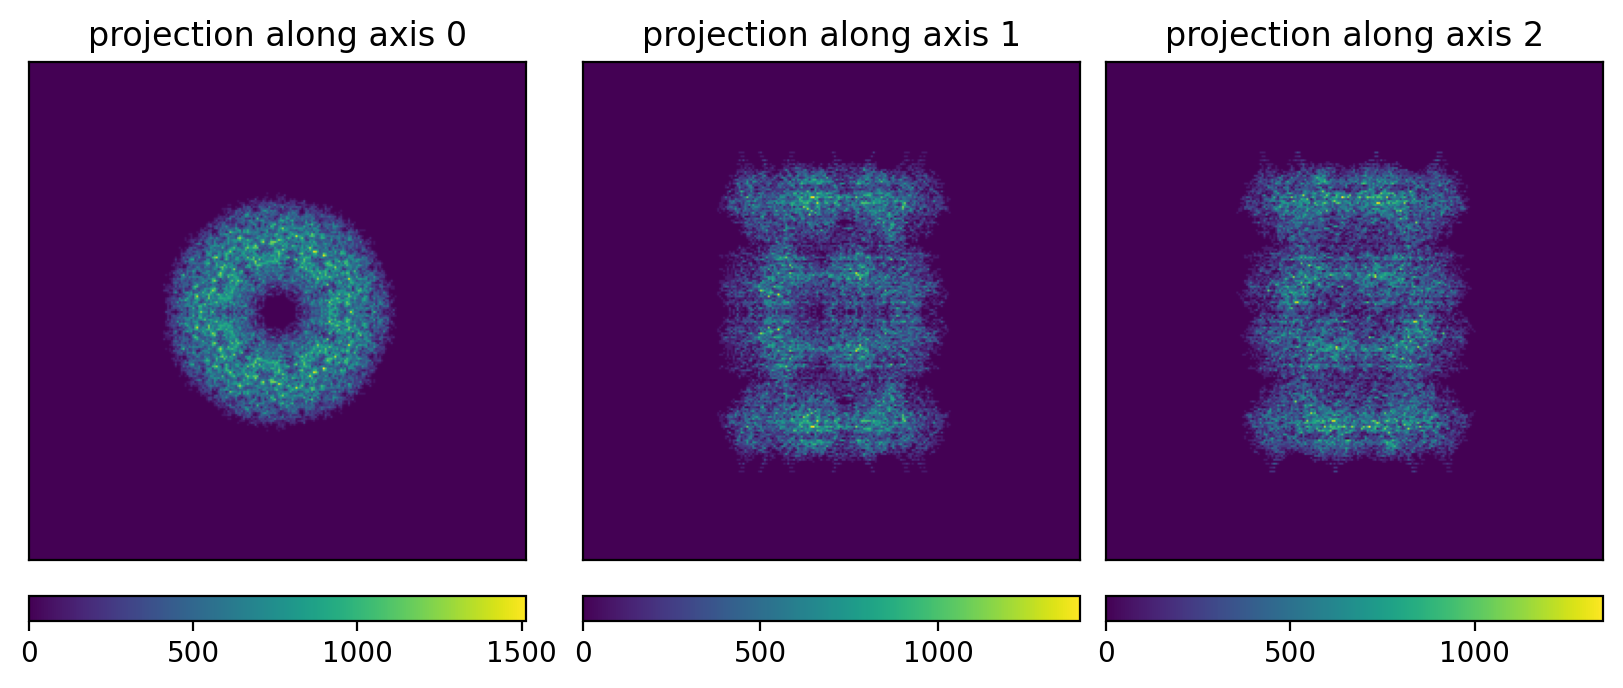

In [9]:
plot3d(vol_snapped_2d)

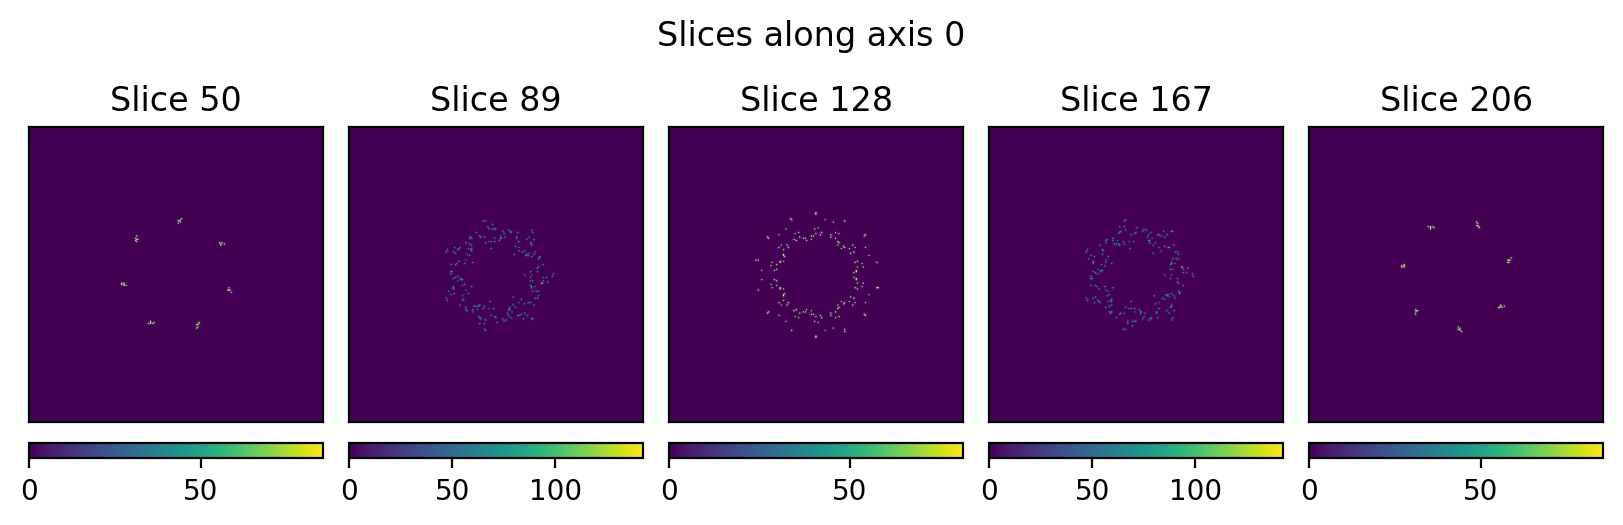

In [10]:
start_idx = 50
plot_slices(vol_snapped_2d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (3D, Snap)

In [11]:
vol_snapped_3d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-3d",
)

46382it [00:06, 7511.90it/s]


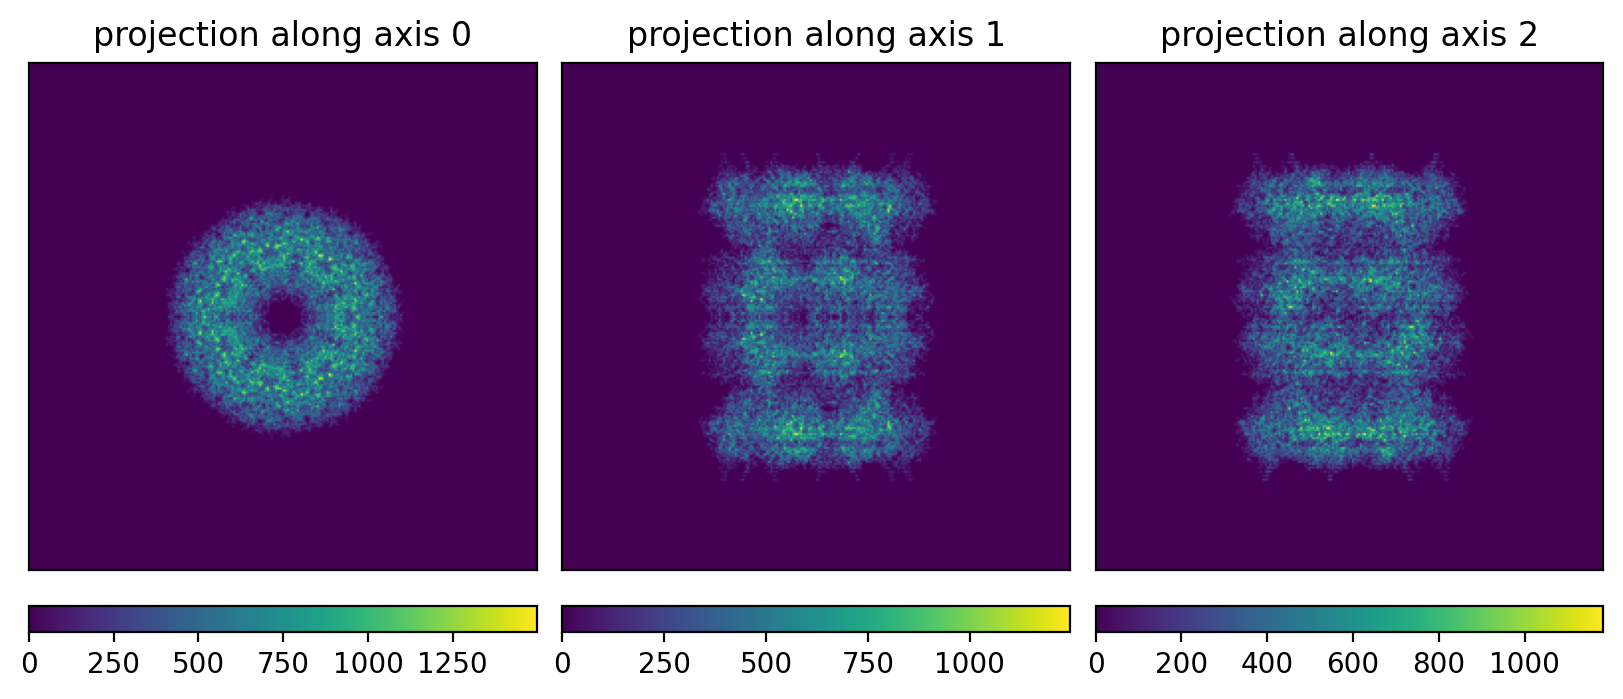

In [12]:
plot3d(vol_snapped_3d)

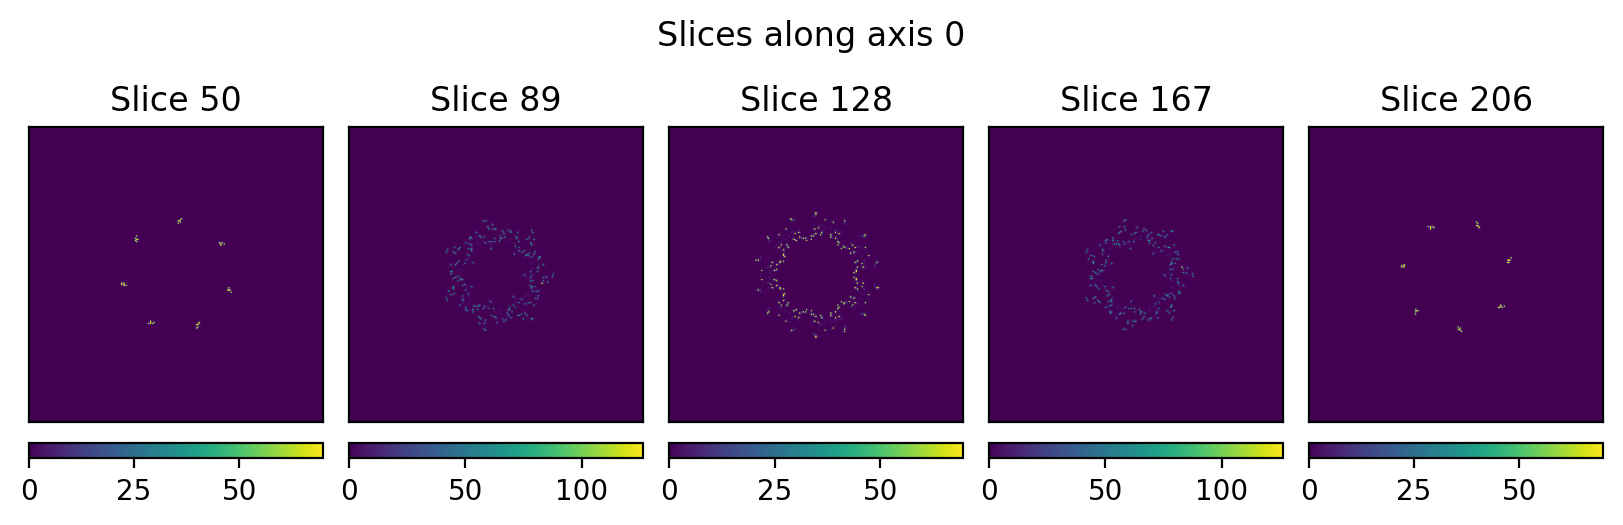

In [13]:
start_idx = 50
plot_slices(vol_snapped_3d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (2D Projection, snap-in-z only)

In [14]:
vol_2d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="2d",
)

46382it [02:39, 290.67it/s]


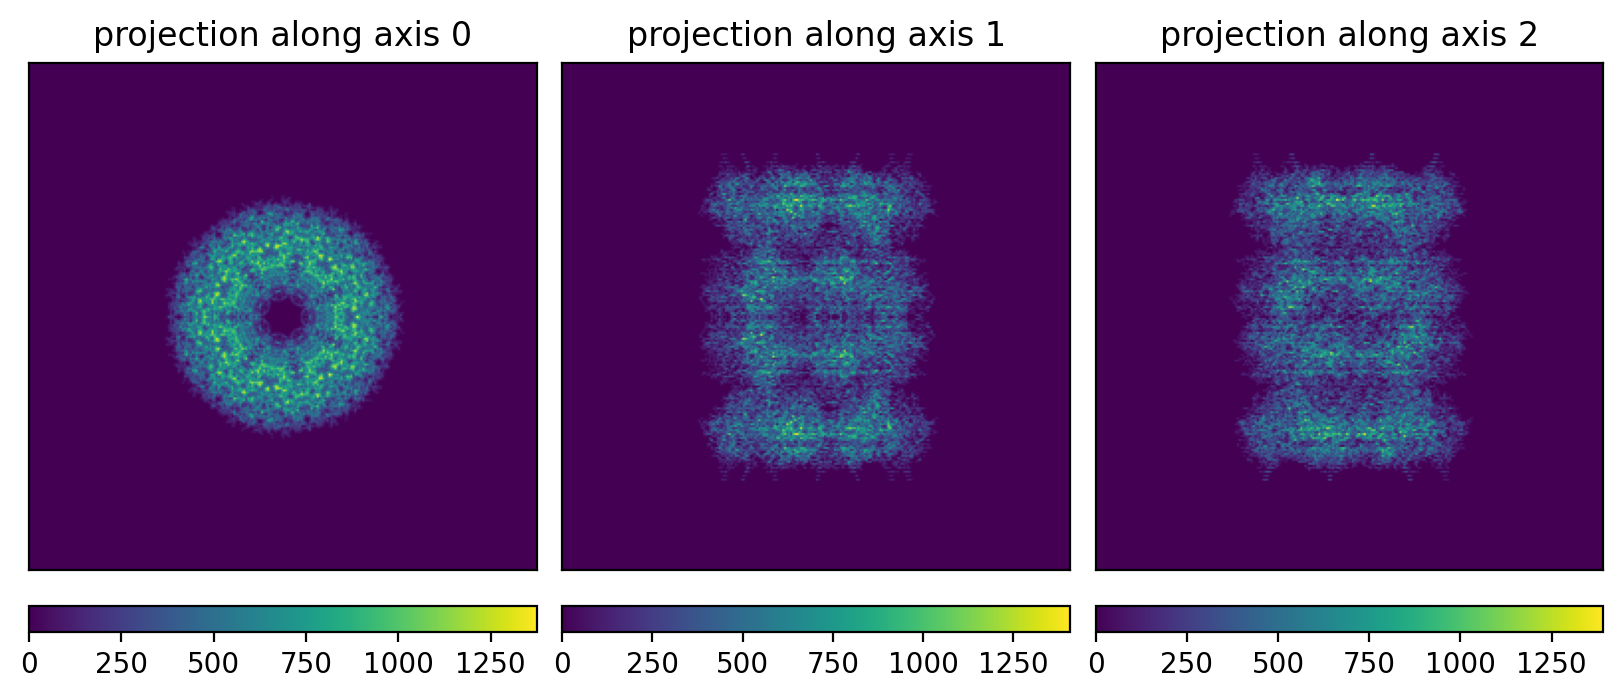

In [15]:
plot3d(vol_2d)

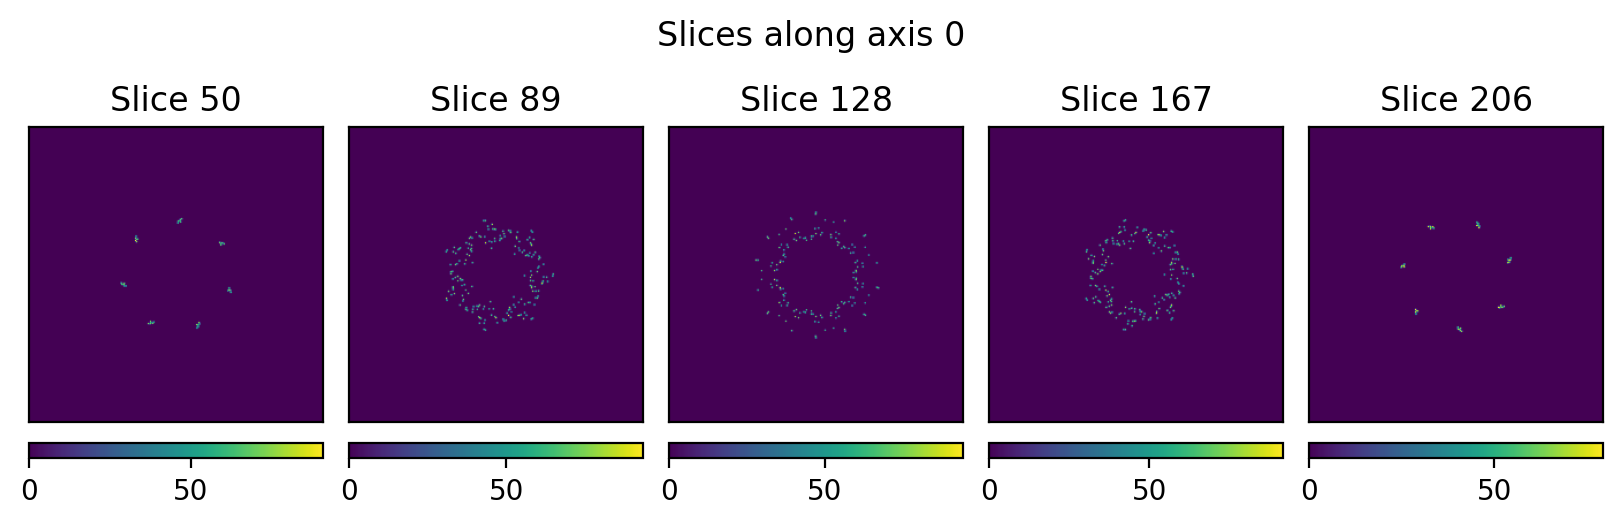

In [16]:
start_idx = 50
plot_slices(vol_2d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (3D, no-snap)

In [17]:
vol_3d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="3d",
)

46382it [02:49, 273.14it/s]


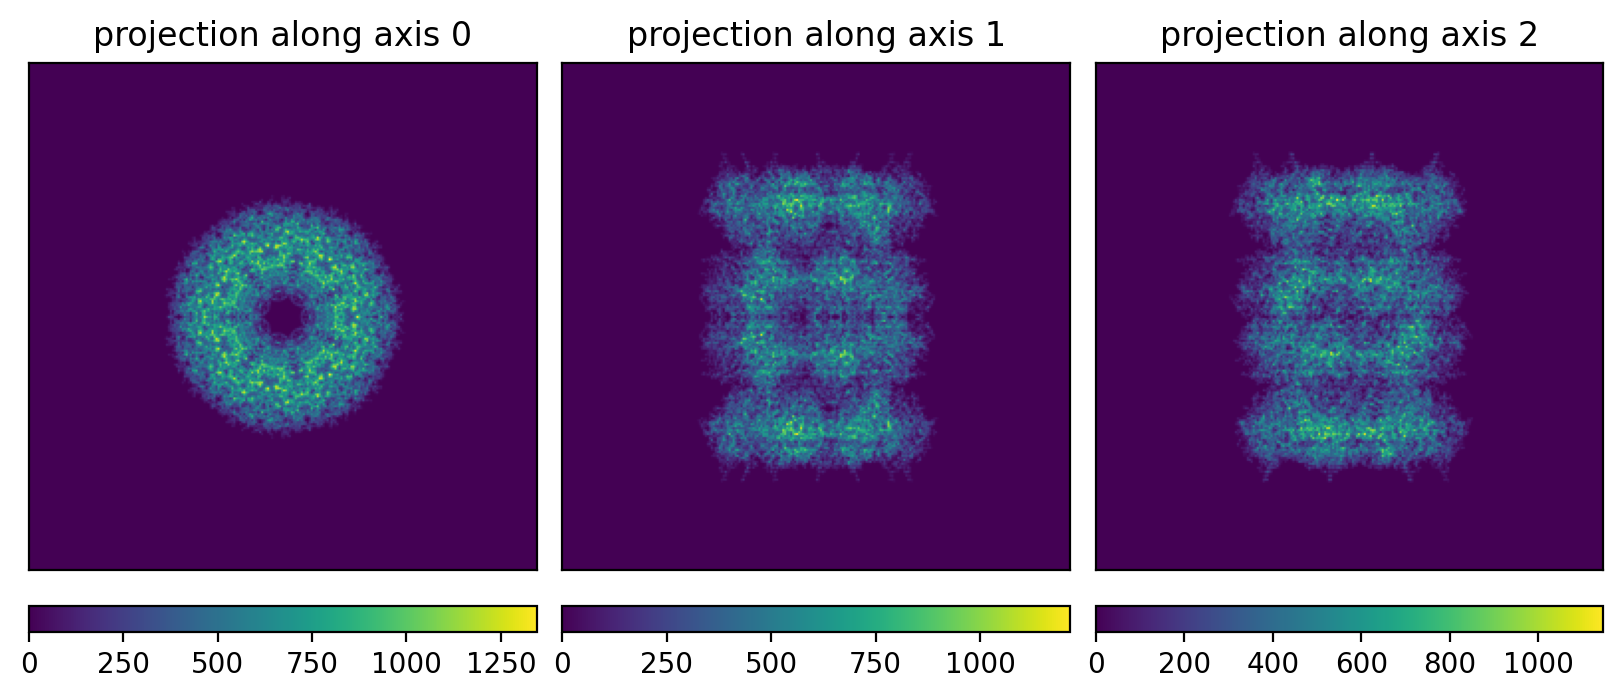

In [18]:
plot3d(vol_3d)

## Compare error between snap and no-snap

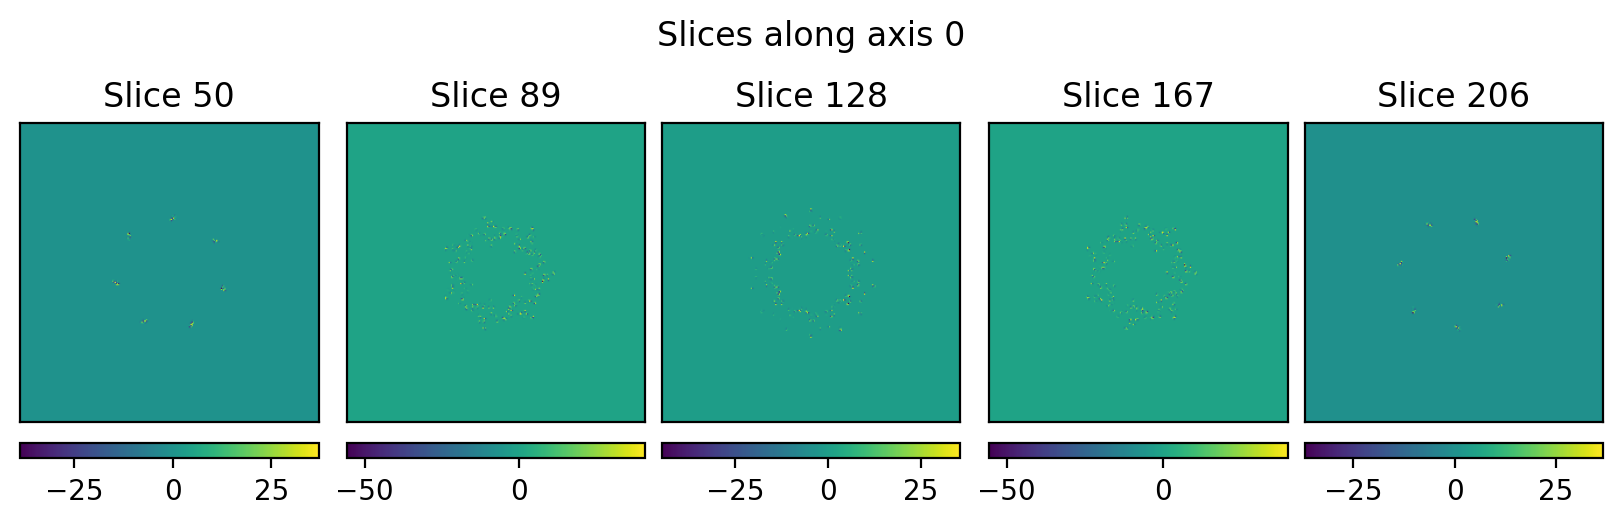

In [19]:
start_idx = 50
plot_slices(vol_2d - vol_snapped_2d, start_idx=start_idx, end_idx=n - start_idx)

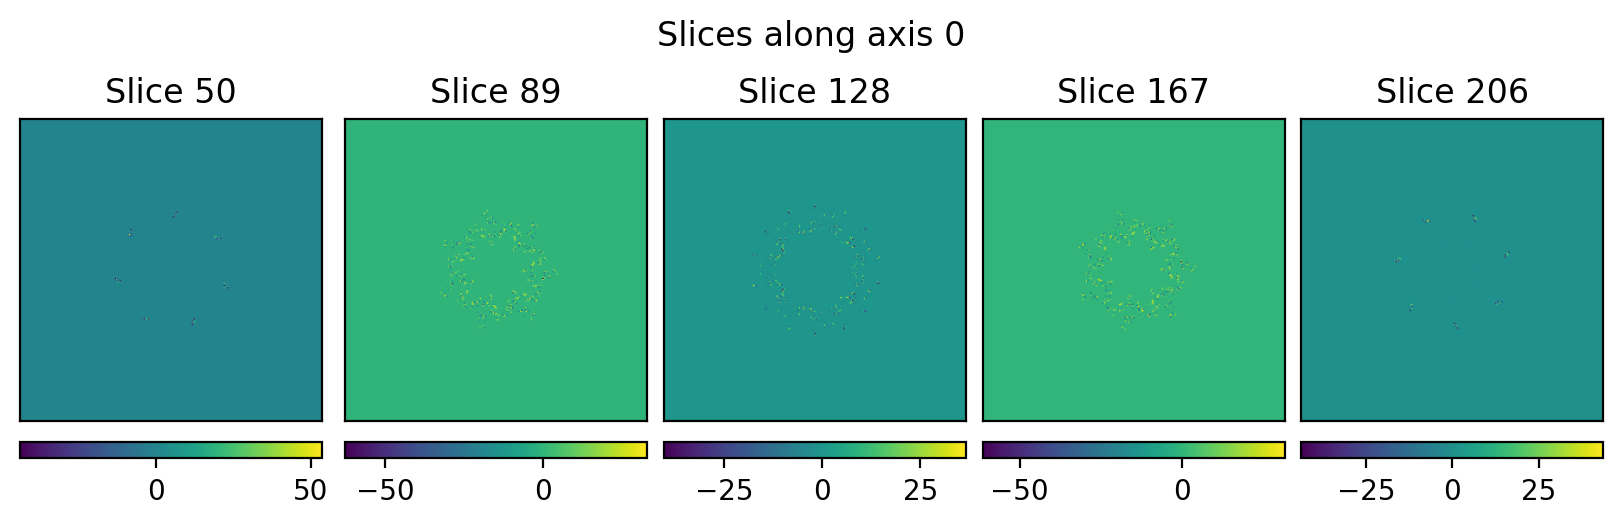

In [20]:
start_idx = 50
plot_slices(vol_3d - vol_snapped_3d, start_idx=start_idx, end_idx=n - start_idx)